In [1]:
# Cell 1 - Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [2]:
# Cell 2 - Load Dataset
data = pd.read_csv(r"C:\Users\HP 15\Downloads\archive (6)\Iris.csv")

data.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [3]:
# Cell 3 - Check Dataset Info
print(data.shape)

print(data.columns)

print(data.isnull().sum())

(150, 6)
Index(['Id', 'SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm',
       'Species'],
      dtype='object')
Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64


In [4]:
# Cell 4 - Select Features and Target
X = data.iloc[:, 1:5]

y = data['Species']

In [5]:
# Cell 5 - Split Dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=10
)

In [6]:
# Cell 6 - Feature Scaling
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [7]:
# Cell 7 - Create KNN Model
model = KNeighborsClassifier(
    n_neighbors=5,
    metric='minkowski'
)

model.fit(X_train, y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [8]:
# Cell 8 - Prediction
y_pred = model.predict(X_test)

print(y_pred)

['Iris-versicolor' 'Iris-virginica' 'Iris-setosa' 'Iris-versicolor'
 'Iris-setosa' 'Iris-versicolor' 'Iris-virginica' 'Iris-versicolor'
 'Iris-setosa' 'Iris-versicolor' 'Iris-versicolor' 'Iris-virginica'
 'Iris-versicolor' 'Iris-setosa' 'Iris-setosa' 'Iris-virginica'
 'Iris-versicolor' 'Iris-setosa' 'Iris-setosa' 'Iris-setosa'
 'Iris-virginica' 'Iris-virginica' 'Iris-virginica' 'Iris-setosa'
 'Iris-versicolor' 'Iris-setosa' 'Iris-versicolor' 'Iris-versicolor'
 'Iris-versicolor' 'Iris-virginica' 'Iris-versicolor' 'Iris-versicolor'
 'Iris-virginica' 'Iris-virginica' 'Iris-virginica' 'Iris-setosa'
 'Iris-virginica' 'Iris-virginica']


In [9]:
# Cell 9 - Accuracy
acc = accuracy_score(y_test, y_pred)

print("Accuracy :", acc)

Accuracy : 0.9736842105263158


In [10]:
# Cell 10 - Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[11  0  0]
 [ 0 14  1]
 [ 0  0 12]]


In [11]:
# Cell 11 - Classification Report
report = classification_report(y_test, y_pred)

print(report)

                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        11
Iris-versicolor       1.00      0.93      0.97        15
 Iris-virginica       0.92      1.00      0.96        12

       accuracy                           0.97        38
      macro avg       0.97      0.98      0.98        38
   weighted avg       0.98      0.97      0.97        38



In [12]:
# Cell 12 - Find Best K Value
accuracy = []

for i in range(1, 15):
    
    knn = KNeighborsClassifier(n_neighbors=i)
    
    knn.fit(X_train, y_train)
    
    pred_i = knn.predict(X_test)
    
    accuracy.append(accuracy_score(y_test, pred_i))

print(accuracy)

[0.9736842105263158, 0.9736842105263158, 0.9736842105263158, 0.9736842105263158, 0.9736842105263158, 1.0, 0.9473684210526315, 0.9473684210526315, 0.9473684210526315, 0.9736842105263158, 0.9736842105263158, 1.0, 1.0, 1.0]


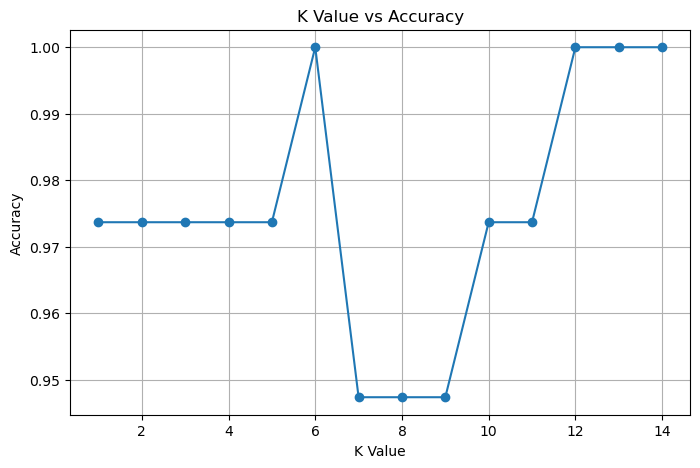

In [13]:
# Cell 13 - Plot Accuracy Graph
plt.figure(figsize=(8,5))

plt.plot(range(1,15), accuracy, marker='o')

plt.xlabel("K Value")

plt.ylabel("Accuracy")

plt.title("K Value vs Accuracy")

plt.grid()

plt.show()